# Linear Support Vector Machines

**Recitation by Dr. Stephanie Milani**

Please make a copy of this recitation in your own Google Drive!

Today you’ll work hands-on with Support Vector Machines (SVMs) in small groups.
You’ll explore:
*   How linear SVMs compare to logistic regression, and
*   What happens when data are not linearly separable.

Please:

*  Work in pairs or trios.
*  Discuss your reasoning with each other.
*  Write short answers in the markdown cells provided.



## SVMs

In yesterday’s lecture, you were introduced to a new type of model: SVM. SVMs aim to find the boundary that maximizes the margin between classes, relying only on a few critical data points called support vectors. This makes them robust to noise and effective in high-dimensional spaces, and with kernels, they can also capture nonlinear relationships. If you have a small dataset, an SVM might still be a good choice over a deep neural network!


Now, please go ahead and split into your groups!

## Breast Cancer Classification

This recitation we will study another very useful application of machine learning in health care.

We will be using the [Breast Cancer Wisconsin (Diagnostic) dataset](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic), which has collections of digitized images of breast masses and labels as whether the mass had been diagnosed with malign tumors.


The dataset is available on the sklearn library, and we can load it as follows.

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

cancer_dataset = load_breast_cancer() # Load the data and convert to a pandas dataframe
df = pd.DataFrame(cancer_dataset.data, columns=cancer_dataset.feature_names)
df['target'] = pd.Series(cancer_dataset.target)

print(df.head()) # Print out the first five data points.

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

Let's gather a few summary statistics about our data.

N = 569 data points


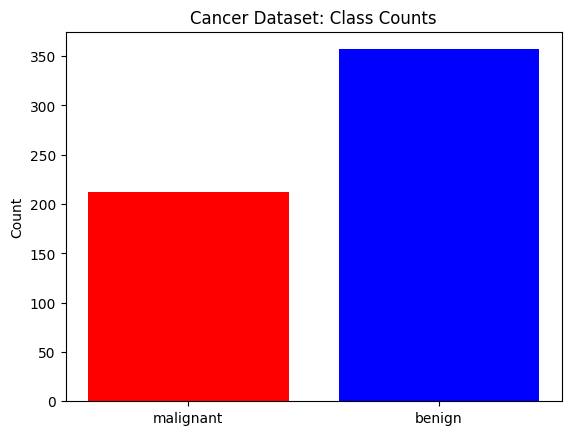

In [2]:
import matplotlib.pyplot as plt

N = len(df) # The number of data points.
print('N = {:d} data points'.format(N))

# Give a barplot of each class.
plt.figure()
plt.bar([0,1], df['target'].value_counts(ascending = True), color = ['r', 'b'], tick_label = cancer_dataset.target_names)
plt.ylabel('Count')
plt.title('Cancer Dataset: Class Counts');

We can now prepare to use the dataset for building our model. We split it into training and validation set using the Scikit-learn functions.

In [3]:
from sklearn import model_selection

x = cancer_dataset.data   # The features.
y = cancer_dataset.target # The targets.

# Print the dataset sizes.
print('Shape of X = ', x.shape)
print('Shape of y = ', y.shape)

# Split the data into a training and test set.
x_train, x_val, y_train, y_val = model_selection.train_test_split(x, y, test_size = 0.33, random_state=7)

Shape of X =  (569, 30)
Shape of y =  (569,)


Using the data sets we prepared, we will train a linear SVM using Scikit-learn. We can also build a logistic regression model using Scikit-learn to compare the performance of each algorithm.

In [4]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

# Train the linear SVM.

svm = LinearSVC(dual = False) # Uses the squared-hinge loss function when fitting the model
svm.fit(x_train, y_train)

# Now evaluate it on the test points
y_pred = svm.predict(x_val)

acc = metrics.accuracy_score(y_val, y_pred)
print('Linear SVM validation accuracy = {:0.1f}%'.format(100*acc))

# Compare to a simple logistic regression model
lr = LogisticRegression(solver = 'liblinear')
lr.fit(x_train, y_train)
y_pred = lr.predict(x_val)

acc = metrics.accuracy_score(y_val, y_pred)
print('Logistic Regression validation accuracy = {:0.1f}%'.format(100*acc))

Linear SVM validation accuracy = 95.7%
Logistic Regression validation accuracy = 95.2%


**Discuss and record:**
1. Which model performs better?
2. What do you think the main difference between their objectives is?

*Enter response here.*

### 🔍 Logistic Regression vs. Linear SVM

| Model | What it Optimizes | How it Treats Points | Key Difference |
|:------|:------------------|:----------------------|:----------------|
| **Logistic Regression** | Uses the **logistic loss** | Every point contributes to the loss | Tries to fit probabilities that explain *all* data points |
| **Linear SVM** | Uses the **hinge loss** | Ignores points that are correctly classified with a large margin. | Focuses only on *difficult* or *borderline* points |

---

### Intuition

Both models learn a linear boundary $w^\top x + b = 0 $,  but they differ in what “doing well” means:

- **Logistic regression**: “Make all predictions confident.”  
  - It continuously pushes every $ y_i(w^\top x_i + b) $ to be large and positive.  
  - There’s no sharp cutoff, so even easy points affect training.

- **SVM**: “Find the simplest (largest-margin) separator that gets the hard points right.”  
  - Once a point is far enough on the correct side, its loss becomes zero.  
  - Only a few points near the boundary, the **support vectors**, determine the classifier.


Now let's see the difference!

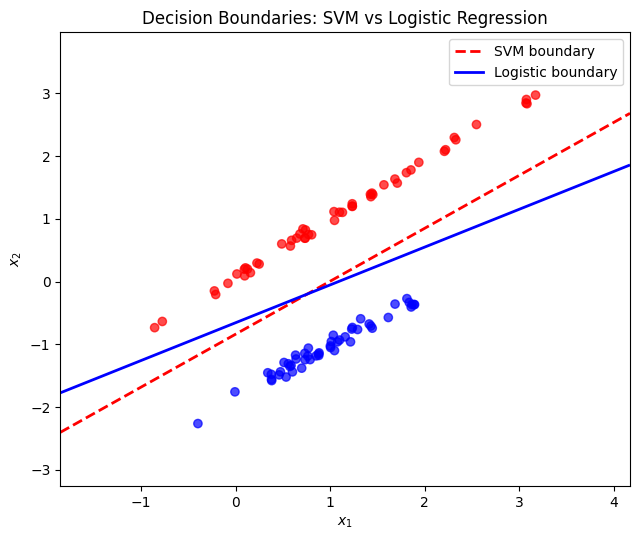

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from matplotlib.lines import Line2D

# Generate data
X, y = make_classification(
    n_samples=100, n_features=2, n_redundant=0,
    n_informative=2, random_state=42, n_clusters_per_class=1
)
y = 2*y - 1

# Fit models
svm = LinearSVC(C=1.0)
lr = LogisticRegression(C=1.0)
svm.fit(X, y)
lr.fit(X, y)

# Setup and plot
x_min, x_max = X[:,0].min() - 1.0, X[:,0].max() + 1.0
y_min, y_max = X[:,1].min() - 1.0, X[:,1].max() + 1.0
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
grid = np.c_[xx.ravel(), yy.ravel()]
Z_svm = svm.decision_function(grid).reshape(xx.shape)
Z_lr  = lr.decision_function(grid).reshape(xx.shape)


plt.figure(figsize=(6.5, 5.5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7)

plt.contour(xx, yy, Z_svm, levels=[0], colors='r', linestyles='--', linewidths=2)
plt.contour(xx, yy, Z_lr,  levels=[0], colors='b', linestyles='-',  linewidths=2)

legend_handles = [
    Line2D([0], [0], color='r', linestyle='--', linewidth=2, label='SVM boundary'),
    Line2D([0], [0], color='b', linestyle='-',  linewidth=2, label='Logistic boundary'),
]
plt.legend(handles=legend_handles, loc='best')

plt.title("Decision Boundaries: SVM vs Logistic Regression")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.tight_layout()
plt.show()

**Discuss and record:**
1. Do the two decision lines coincide exactly?
2. Why does SVM often yield larger-margin solutions?


*Enter response here.*

When you are finished discussing with your team, please raise your hand!


---



## Case of non-linearly separable dataset

If the data is linear separable, then a linear SVM should be able to achieve 100% accuracy.  However, this is rarely the case since even the breast cancer dataset was not exactly linear separable! In general, real-world data are rarely that clean; different groups often overlap.  

By increasing the variance or moving the clusters closer together, we simulate this overlap.  

This helps us see what happens when a linear model struggles and why we sometimes need soft margins or non-linear (kernel) SVMs to handle more complex boundaries.

## Exercise 1

We'll use a fake dataset to illustrate this. This data is drawn from a bi-modal Gaussian mixture model.

Increasing the factor in front of the covariances or shifting the centers of the two distributions to be closer to each other will cause the data to overlap more, making it harder to classify. Let's see how that would look.

In [6]:
"""
Input:
    N : the number of data points

Output:
    X, y : the features and targets of shapes (N,2) and (N, )
"""

import numpy as np

def sample_bimodal_data(N, mu1=[1,0], mu2=[-1,0]):
    # The two modes and covariances.
    mu1 = np.asarray(mu1)
    mu2 = np.asarray(mu2)

    cov1 = 5 * np.identity(2)
    cov2 = 5 * np.identity(2)

    N1 = N//2   # Number of points in first class.
    N2 = N - N1 # Number of points in second class.

    # Sample the random points.
    X1 = np.random.multivariate_normal(mu1, cov1, N1)
    X2 = np.random.multivariate_normal(mu2, cov2, N2)
    Y1 = np.zeros(N1)
    Y2 = np.ones(N2)

    # Combine the data.
    X = np.vstack((X1, X2))
    Y = np.concatenate((Y1, Y2), axis = None)

    return X,Y

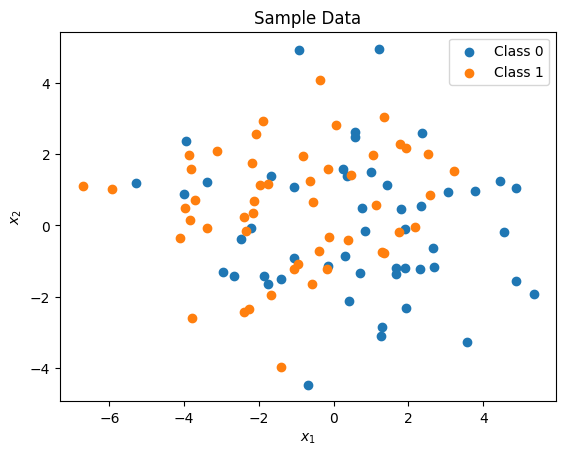

In [7]:
# Plot the sample data.
N = 100
X,Y = sample_bimodal_data(N)

plt.figure(1)
plt.scatter(X[:N//2, 0], X[:N//2, 1], label = 'Class 0')
plt.scatter(X[N - N//2:, 0], X[N - N//2:, 1], label = 'Class 1')
plt.legend()
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.title('Sample Data');

In [8]:
# To-do: Change the sample bi_modal_data function such that
# the two multivariate distributions have similar means,
# create a plot with the samples from the two distributions


In [20]:
import numpy as np

def sample_bimodal_data_similar_means(N, mean=(0.0, 0.0), delta=0.1, seed=42):
    """
    Two 2D Gaussians with *similar means* and different covariances.

    Args:
        N (int): total number of samples
        mean (tuple): shared center
        delta (float): tiny offset so means are 'similar' not identical
        seed (int): RNG seed for reproducibility
    Returns:
        X: (N, 2), y: (N,)
    """
    rng = np.random.default_rng(seed)
    mean = np.asarray(mean, float)

    mu1 = mean + np.array([ delta, 0.0])
    mu2 = mean + np.array([-delta, 0.0])

    # different shapes/rotations
    cov1 = np.array([[4.0,  1.8],
                     [1.8,  3.0]])
    cov2 = np.array([[3.0, -1.2],
                     [-1.2, 4.5]])

    n1 = N // 2
    n2 = N - n1

    X1 = rng.multivariate_normal(mu1, cov1, size=n1)
    X2 = rng.multivariate_normal(mu2, cov2, size=n2)

    y1 = np.zeros(n1, dtype=int)
    y2 = np.ones(n2, dtype=int)

    X = np.vstack([X1, X2])
    y = np.concatenate([y1, y2])
    return X, y


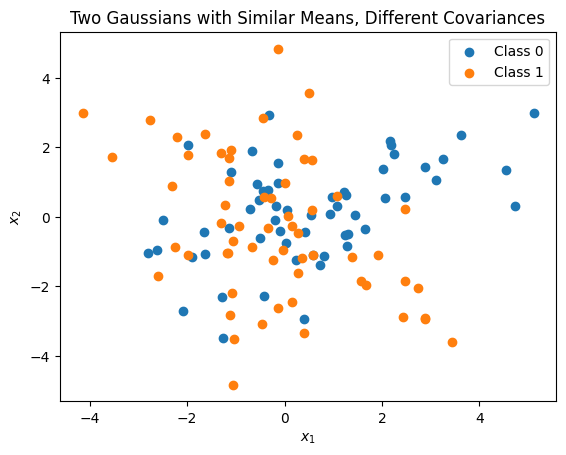

In [21]:
import matplotlib.pyplot as plt

X, y = sample_bimodal_data_similar_means(N=120, mean=(0,0), delta=0.05, seed=7)

plt.figure()
plt.scatter(X[y==0,0], X[y==0,1], label='Class 0')
plt.scatter(X[y==1,0], X[y==1,1], label='Class 1')
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.title('Two Gaussians with Similar Means, Different Covariances')
plt.legend()
plt.show()


#### Using a slack variable C

Since the data is not perfectly linearly separable you'll want to use a slack variable which allows SVM to handle this dataset.

Implement the SVM model to use with a slack variable. Compute the accuracy of the SVM model with the slack variable, print it, and then create a scatter plot of the data and the predicted classes. You should use different colors or symbols for the different classes.

In [9]:
# To-do: Get the data and split it into training and testing (use 70/30 split)

In [10]:
# To-do: Define the SVM model to use with a slack variable, fit the model, and print the accuracy

# To-do: Create a scatter plot

## Exercise 2

Now you will see how the separation between the two class centers (μ₁ and μ₂) affects how well a linear model can classify the data.

You will:
1. Modify the means (`mu1` and `mu2`) inside `sample_bimodal_data()` so that the two clusters move closer together.  
   - Example: try `mu1 = [-2, 0]`, `mu2 = [2, 0]`, then `mu1 = [-1, 0]`, `mu2 = [1, 0]`, and finally `mu1 = [-0.5, 0]`, `mu2 = [0.5, 0]`.  
2. For each pair of means:
   - Generate the data.  
   - Train an SVM and record its train and test accuracy.
   - Train a simple logistic regression model and record its train and test accuracy.   
3. Observe how accuracy changes as the clusters overlap more.

In [11]:
# To-do: Train an SVM with the data sets
# you create with different values and observe the change in accuracy
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

Let's train some models with different $C$ and compare them use cross-validation!

You will:
1. Define different SVM models to use, each with a different value of C. Try: 10, 1, 1e-3, 1e-7.

2. Use model_selection to get 5 KFold splits. Then compute the cross validation scores. Finally, print the average scores for each model.


In [12]:
from sklearn import model_selection

# To-do: Define the different SVM models to use
# To-do: Compute the cross validation scores
# To-do: Print the scores for each model

We see that the model performs slightly differently for different values of the slack variable $C$.  

$$
\min_{w,b,\zeta} \frac{1}{2}w^Tw + C\sum_{i=1}^n \zeta_i,\quad \text{ such that }\quad y_i(w^Tx_i + b) \ge 1 - \zeta_i,\quad \zeta_i \ge 0
$$

See the sci-kit [documentation](https://scikit-learn.org/stable/modules/svm.html) for more details.  We can also plot a curve of the validation score for many different $C$ values which can be helpful for determining the optimal hyperparameter.


Now, we want to find the optimal hyperparameter for our model! Let's plot a curve of the validation score for many different values of C.

1. First, use numpy arange to get 20 C values from 1 to 1e-6.

2. Use model_selection to get 10 KFold splits. Then compute the cross validation scores.

3. Plot the curve of the cross validation scores. The x axis should be the C value.

In [13]:
# To-do: Get the C values we want to look at.
# To-do: Compute the cross validation scores
# To-do: Plot the curve

We can use this plot to find the optimal value of the slack variables based on the cross validation score. Now let's see how our 4 models from earlier actually do on the validation set.

In [14]:
# To-do: Define the different SVM models to use
# To-do: Fit the models and make the predictions
# To-do: Evaluate and print the accuracy on validation/test

### If you're curious: more examples of non-linearly separable datasets

In [15]:
"""
Input:
    N : the number of data points

Output:
    X, y : the features and targets of shapes (N,2) and (N, )
"""
def gen_data1(N):
    N1 = N//2
    N2 = N - N1
    t = np.linspace(0, 2*np.pi, N1)

    X1 = np.zeros((N1, 2))
    X1[:,0] = 4*np.cos(t) + 0.1*np.random.randn(N1)
    X1[:,1] = 4*np.sin(t) + 0.1*np.random.randn(N1)
    y1 = np.zeros(N1)

    X2 = np.random.randn(2*N2)
    X2 = X2.reshape((N2, 2))
    y2 = np.ones(N2)

    # Combine the data.
    X = np.vstack((X1, X2))
    y = np.concatenate((y1, y2), axis = None) # axis = None means that arrays flattened before use

    return X,y

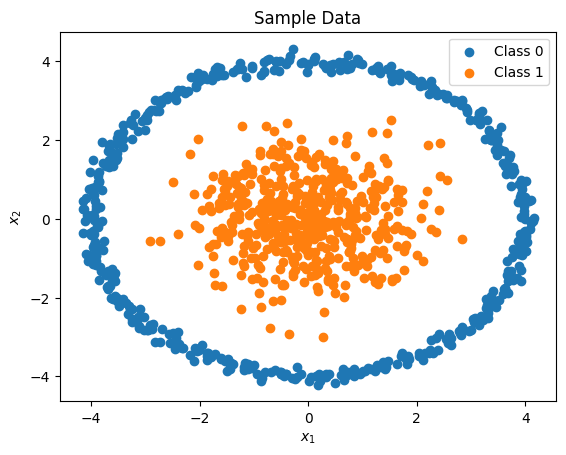

In [16]:
# Plot the data.
N = 1000
X, Y = gen_data1(N)

plt.figure(3)
plt.scatter(X[:N//2, 0], X[:N//2, 1], label = 'Class 0')
plt.scatter(X[N - N//2:, 0], X[N - N//2:, 1], label = 'Class 1')
plt.legend()
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.title('Sample Data');

SVM accuracy = 38.3%


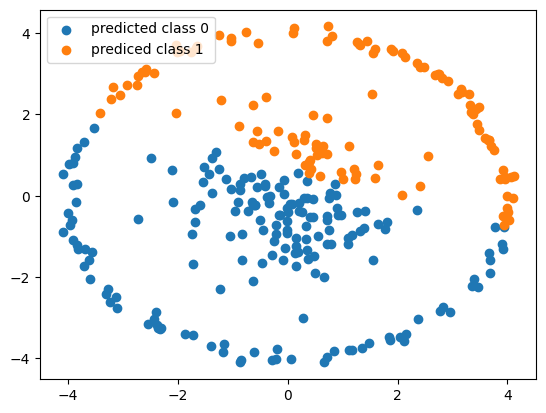

In [17]:
# Define the different SVM models to use
# Use a 70/30 split
X_train, X_val, Y_train, Y_val = model_selection.train_test_split(X, Y, test_size = 0.3, random_state = 981)
svm = LinearSVC(C = 1e+10, dual = False)
svm.fit(X_train, Y_train)
svmpred = svm.predict(X_val)
acc = metrics.accuracy_score(Y_val, svmpred)
print('SVM accuracy = {:0.1f}%'.format(100*acc))

plt.figure(2)
I = svmpred == 0
plt.scatter(X_val[I, 0], X_val[I, 1], label = 'predicted class 0')
I = svmpred == 1
plt.scatter(X_val[I, 0], X_val[I, 1], label = 'prediced class 1')
plt.legend()
plt.show()

Here the data is not linearly separable although we can very clearly see some separation. If we transform the data by only looking at the radius, then we would be able to linearly separate the data.

(1000, 2)


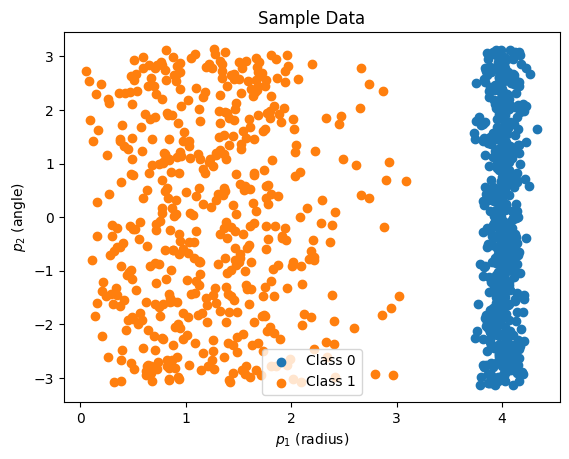

In [18]:
def cart2pol(x, y):
    rho = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    return (rho, phi)

pX = np.vstack(cart2pol(X[:, 0], X[:, 1])).T
print(pX.shape)
plt.figure(4)
plt.scatter(pX[:N//2, 0], pX[:N//2, 1], label = 'Class 0')
plt.scatter(pX[N - N//2:, 0], pX[N - N//2:, 1], label = 'Class 1')
plt.legend()
plt.xlabel(r'$p_1$ (radius)')
plt.ylabel(r'$p_2$ (angle)')
plt.title('Sample Data');

In [19]:
# Define the different SVM models to use
# Use a 70/30 split
X_train, X_val, Y_train, Y_val = model_selection.train_test_split(pX, Y, test_size = 0.3, random_state = 981)
svm = LinearSVC(C = 1e+10, dual = False)
svm.fit(X_train, Y_train)
svmpred = svm.predict(X_val)
acc = metrics.accuracy_score(Y_val, svmpred)
print('SVM accuracy = {:0.1f}%'.format(100*acc))

SVM accuracy = 100.0%


In [23]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# your original sampler (unchanged)
def sample_bimodal_data(N, mu1=[1,0], mu2=[-1,0]):
    mu1, mu2 = np.asarray(mu1), np.asarray(mu2)
    cov1 = 5 * np.identity(2)
    cov2 = 5 * np.identity(2)
    N1 = N//2
    N2 = N - N1
    X1 = np.random.multivariate_normal(mu1, cov1, N1)
    X2 = np.random.multivariate_normal(mu2, cov2, N2)
    y1 = np.zeros(N1, dtype=int)
    y2 = np.ones(N2, dtype=int)
    X = np.vstack([X1, X2])
    y = np.concatenate([y1, y2])
    return X, y

def eval_pair(mu1, mu2, N=600, test_size=0.3, seed=0):
    X, y = sample_bimodal_data(N, mu1=mu1, mu2=mu2)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size, random_state=seed, stratify=y)

    # Pipelines with scaling
    svm = make_pipeline(StandardScaler(),
                        LinearSVC(C=1.0, dual=False, max_iter=10000, random_state=seed))
    logit = make_pipeline(StandardScaler(),
                          LogisticRegression(C=1.0, solver="lbfgs", max_iter=10000))

    svm.fit(Xtr, ytr)
    logit.fit(Xtr, ytr)

    acc = {
        "mu1": mu1, "mu2": mu2,
        "svm_train": accuracy_score(ytr, svm.predict(Xtr)),
        "svm_test":  accuracy_score(yte, svm.predict(Xte)),
        "log_train": accuracy_score(ytr, logit.predict(Xtr)),
        "log_test":  accuracy_score(yte, logit.predict(Xte)),
    }
    return acc

pairs = [
    ([-2, 0], [ 2, 0]),
    ([-1, 0], [ 1, 0]),
    ([-0.5, 0], [ 0.5, 0]),
    ([ 0.0, 0], [ 0.0, 0]),  # identical means
]

results = [eval_pair(mu1, mu2) for mu1, mu2 in pairs]
for r in results:
    print(f"mu1={r['mu1']}, mu2={r['mu2']} | "
          f"SVM train/test: {r['svm_train']:.3f}/{r['svm_test']:.3f} | "
          f"LogReg train/test: {r['log_train']:.3f}/{r['log_test']:.3f}")


mu1=[-2, 0], mu2=[2, 0] | SVM train/test: 0.831/0.778 | LogReg train/test: 0.831/0.778
mu1=[-1, 0], mu2=[1, 0] | SVM train/test: 0.660/0.672 | LogReg train/test: 0.655/0.672
mu1=[-0.5, 0], mu2=[0.5, 0] | SVM train/test: 0.633/0.556 | LogReg train/test: 0.636/0.556
mu1=[0.0, 0], mu2=[0.0, 0] | SVM train/test: 0.510/0.483 | LogReg train/test: 0.510/0.483


Best C: 1.0 CV acc: 0.6666666666666666


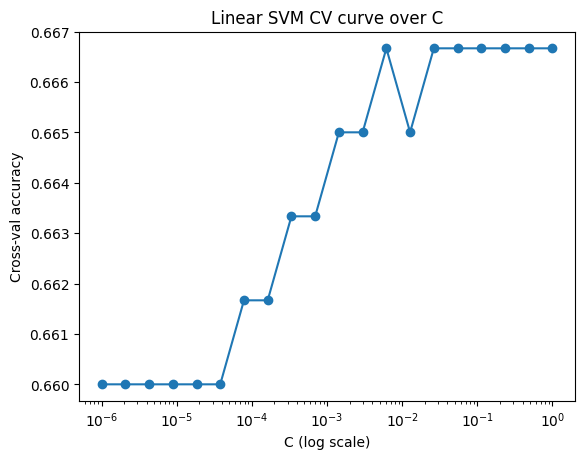

In [22]:
import numpy as np
from sklearn import model_selection
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

# Use one fixed mean pair (tune C on this scenario)
X, y = sample_bimodal_data(600, mu1=[-1,0], mu2=[1,0])

# 20 values from 1 to 1e-6 (log-spaced)
Cs = np.logspace(0, -6, 20)

cv = model_selection.StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
cv_scores = []

for C in Cs:
    clf = make_pipeline(StandardScaler(),
                        LinearSVC(C=C, dual=False, max_iter=10000, random_state=0))
    scores = model_selection.cross_val_score(clf, X, y, cv=cv, scoring="accuracy")
    cv_scores.append(scores.mean())

print("Best C:", Cs[int(np.argmax(cv_scores))], "CV acc:", max(cv_scores))

# Plot
import matplotlib.pyplot as plt
plt.figure()
plt.plot(Cs, cv_scores, marker="o")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Cross-val accuracy")
plt.title("Linear SVM CV curve over C")
plt.show()


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = sample_bimodal_data(800, mu1=[-1,0], mu2=[1,0])
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=1)

Cs_to_try = [10, 1, 1e-3, 1e-7]
for C in Cs_to_try:
    clf = make_pipeline(StandardScaler(),
                        LinearSVC(C=C, dual=False, max_iter=10000, random_state=1))
    clf.fit(Xtr, ytr)
    print(f"C={C:>8}: train={accuracy_score(ytr, clf.predict(Xtr)):.3f} | "
          f"test={accuracy_score(yte, clf.predict(Xte)):.3f}")


C=      10: train=0.707 | test=0.665
C=       1: train=0.707 | test=0.665
C=   0.001: train=0.710 | test=0.665
C=   1e-07: train=0.703 | test=0.670


In [25]:
# your gen_data1 from the prompt is assumed defined

from sklearn.svm import SVC

X, y = gen_data1(1000)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)

lin = make_pipeline(StandardScaler(), LinearSVC(C=1.0, dual=False, max_iter=20000, random_state=0))
rbf = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma="scale", random_state=0))

for name, clf in [("Linear SVM", lin), ("RBF SVM", rbf)]:
    clf.fit(Xtr, ytr)
    print(f"{name}: train={clf.score(Xtr, ytr):.3f} | test={clf.score(Xte, yte):.3f}")


Linear SVM: train=0.497 | test=0.503
RBF SVM: train=0.991 | test=0.997
